# 04 - Model Evaluation
## Loan Risk Assessment System

**Objective:** Evaluate all three trained models on the held-out test set using Accuracy, Precision, Recall, F1 Score, and ROC-AUC, and generate confusion matrices, a combined ROC curve, and feature importance plots.

**Workflow:**
1. Load persisted models and test data
2. Compute predictions & metrics per model
3. Confusion matrices
4. Combined ROC curve
5. Feature importance (Random Forest)
6. Build final model comparison table

In [1]:
import sys
sys.path.append('..')

import pandas as pd
from IPython.display import Image, display
from src import config
from src.utils import load_object
from src.evaluation import evaluate_model, build_comparison_table, get_best_model_name
from src.visualization import (
    plot_confusion_matrix, plot_combined_roc_curve,
    plot_feature_importance, plot_model_comparison
)

train_df = pd.read_csv(config.TRAIN_DATA_PATH)
test_df = pd.read_csv(config.TEST_DATA_PATH)
X_test = test_df.drop(columns=[config.TARGET_COLUMN])
y_test = test_df[config.TARGET_COLUMN]

log_reg = load_object(config.MODELS_DIR / config.MODEL_FILENAMES['logistic_regression'])
decision_tree = load_object(config.MODELS_DIR / config.MODEL_FILENAMES['decision_tree'])
random_forest = load_object(config.MODELS_DIR / config.MODEL_FILENAMES['random_forest'])
scaler = load_object(config.MODELS_DIR / config.MODEL_FILENAMES['scaler'])

X_test_scaled = scaler.transform(X_test)
models = {'Logistic Regression': log_reg, 'Decision Tree': decision_tree, 'Random Forest': random_forest}

[2026-07-31 19:28:17] INFO - loan_risk_assessment - Loaded object from: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/models/logistic_regression.pkl


[2026-07-31 19:28:17] INFO - loan_risk_assessment - Loaded object from: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/models/decision_tree.pkl


[2026-07-31 19:28:18] INFO - loan_risk_assessment - Loaded object from: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/models/random_forest.pkl


[2026-07-31 19:28:18] INFO - loan_risk_assessment - Loaded object from: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/models/scaler.pkl


## Per-Model Evaluation

For each model, we compute Accuracy, Precision, Recall, F1 Score, and ROC-AUC, then plot a confusion matrix.


EVALUATION REPORT - LOGISTIC REGRESSION
Accuracy    : 0.7154
Precision   : 0.8132
Recall      : 0.8043
F1 Score    : 0.8087
ROC AUC     : 0.6739

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.44      0.45      0.44        31
Approved (1)       0.81      0.80      0.81        92

    accuracy                           0.72       123
   macro avg       0.63      0.63      0.63       123
weighted avg       0.72      0.72      0.72       123



[2026-07-31 19:28:18] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/logistic_confusion_matrix.png


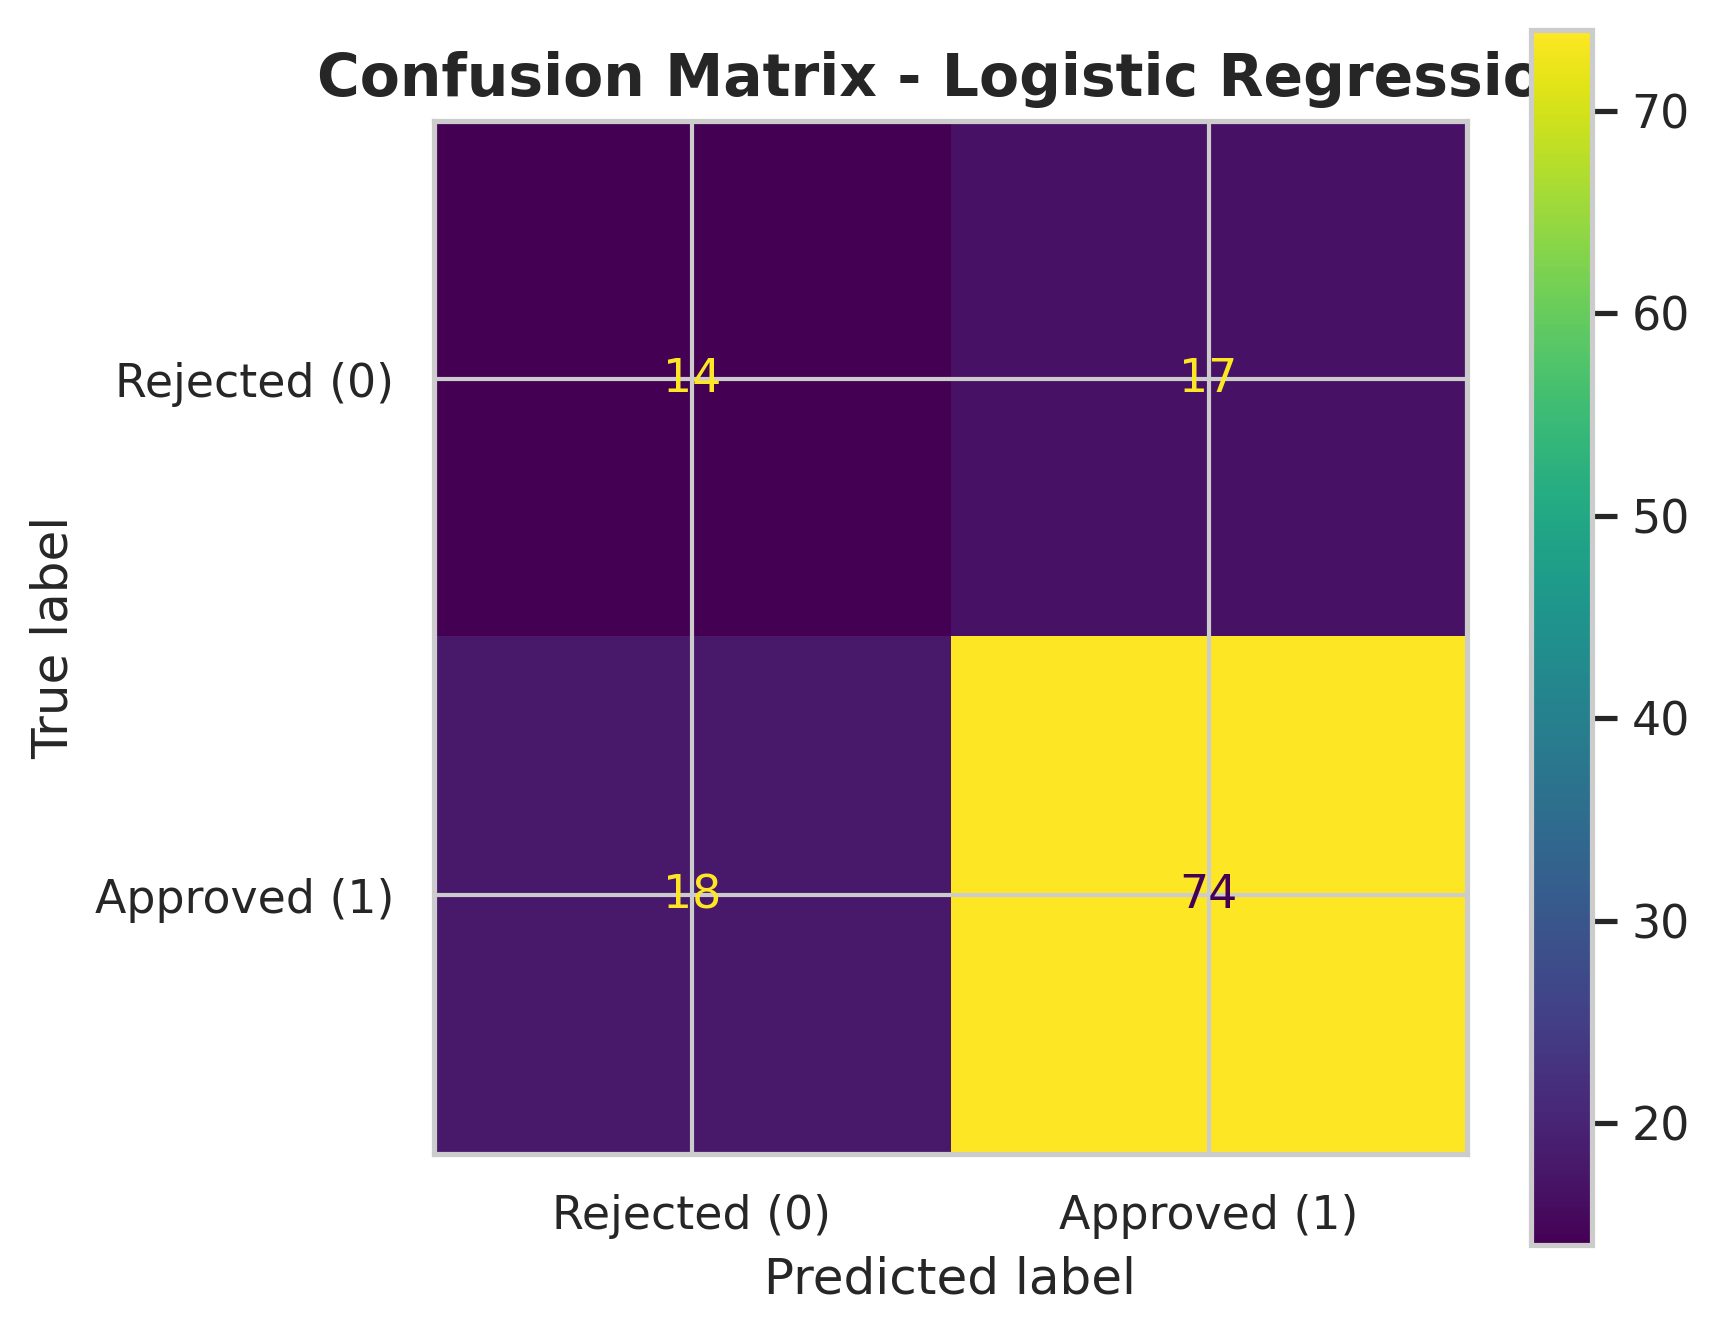


EVALUATION REPORT - DECISION TREE
Accuracy    : 0.7073
Precision   : 0.8111
Recall      : 0.7935
F1 Score    : 0.8022
ROC AUC     : 0.6648

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.42      0.45      0.44        31
Approved (1)       0.81      0.79      0.80        92

    accuracy                           0.71       123
   macro avg       0.62      0.62      0.62       123
weighted avg       0.71      0.71      0.71       123



[2026-07-31 19:28:18] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/decision_tree_confusion_matrix.png


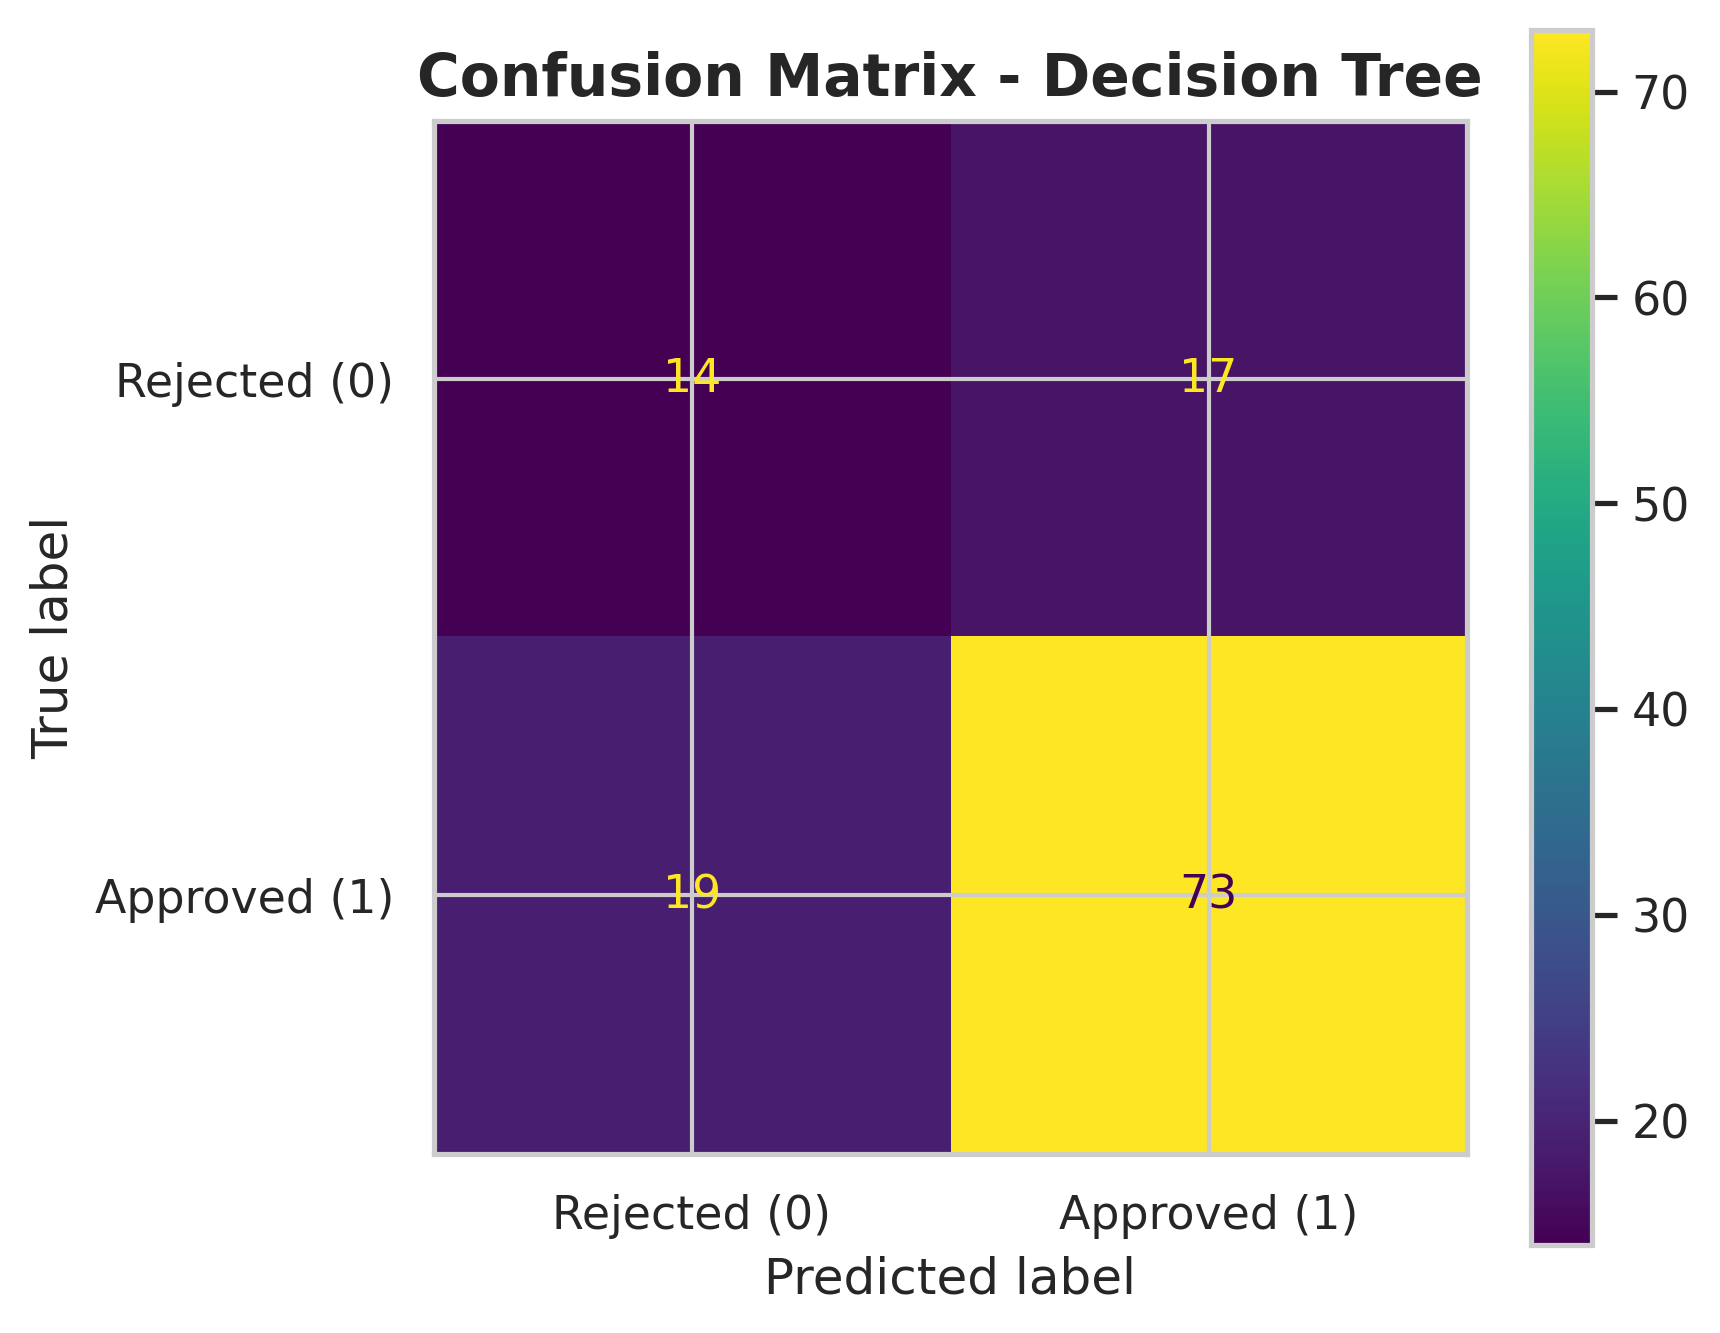


EVALUATION REPORT - RANDOM FOREST
Accuracy    : 0.7480
Precision   : 0.8020
Recall      : 0.8804
F1 Score    : 0.8394
ROC AUC     : 0.6855

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.50      0.35      0.42        31
Approved (1)       0.80      0.88      0.84        92

    accuracy                           0.75       123
   macro avg       0.65      0.62      0.63       123
weighted avg       0.73      0.75      0.73       123



[2026-07-31 19:28:19] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/random_forest_confusion_matrix.png


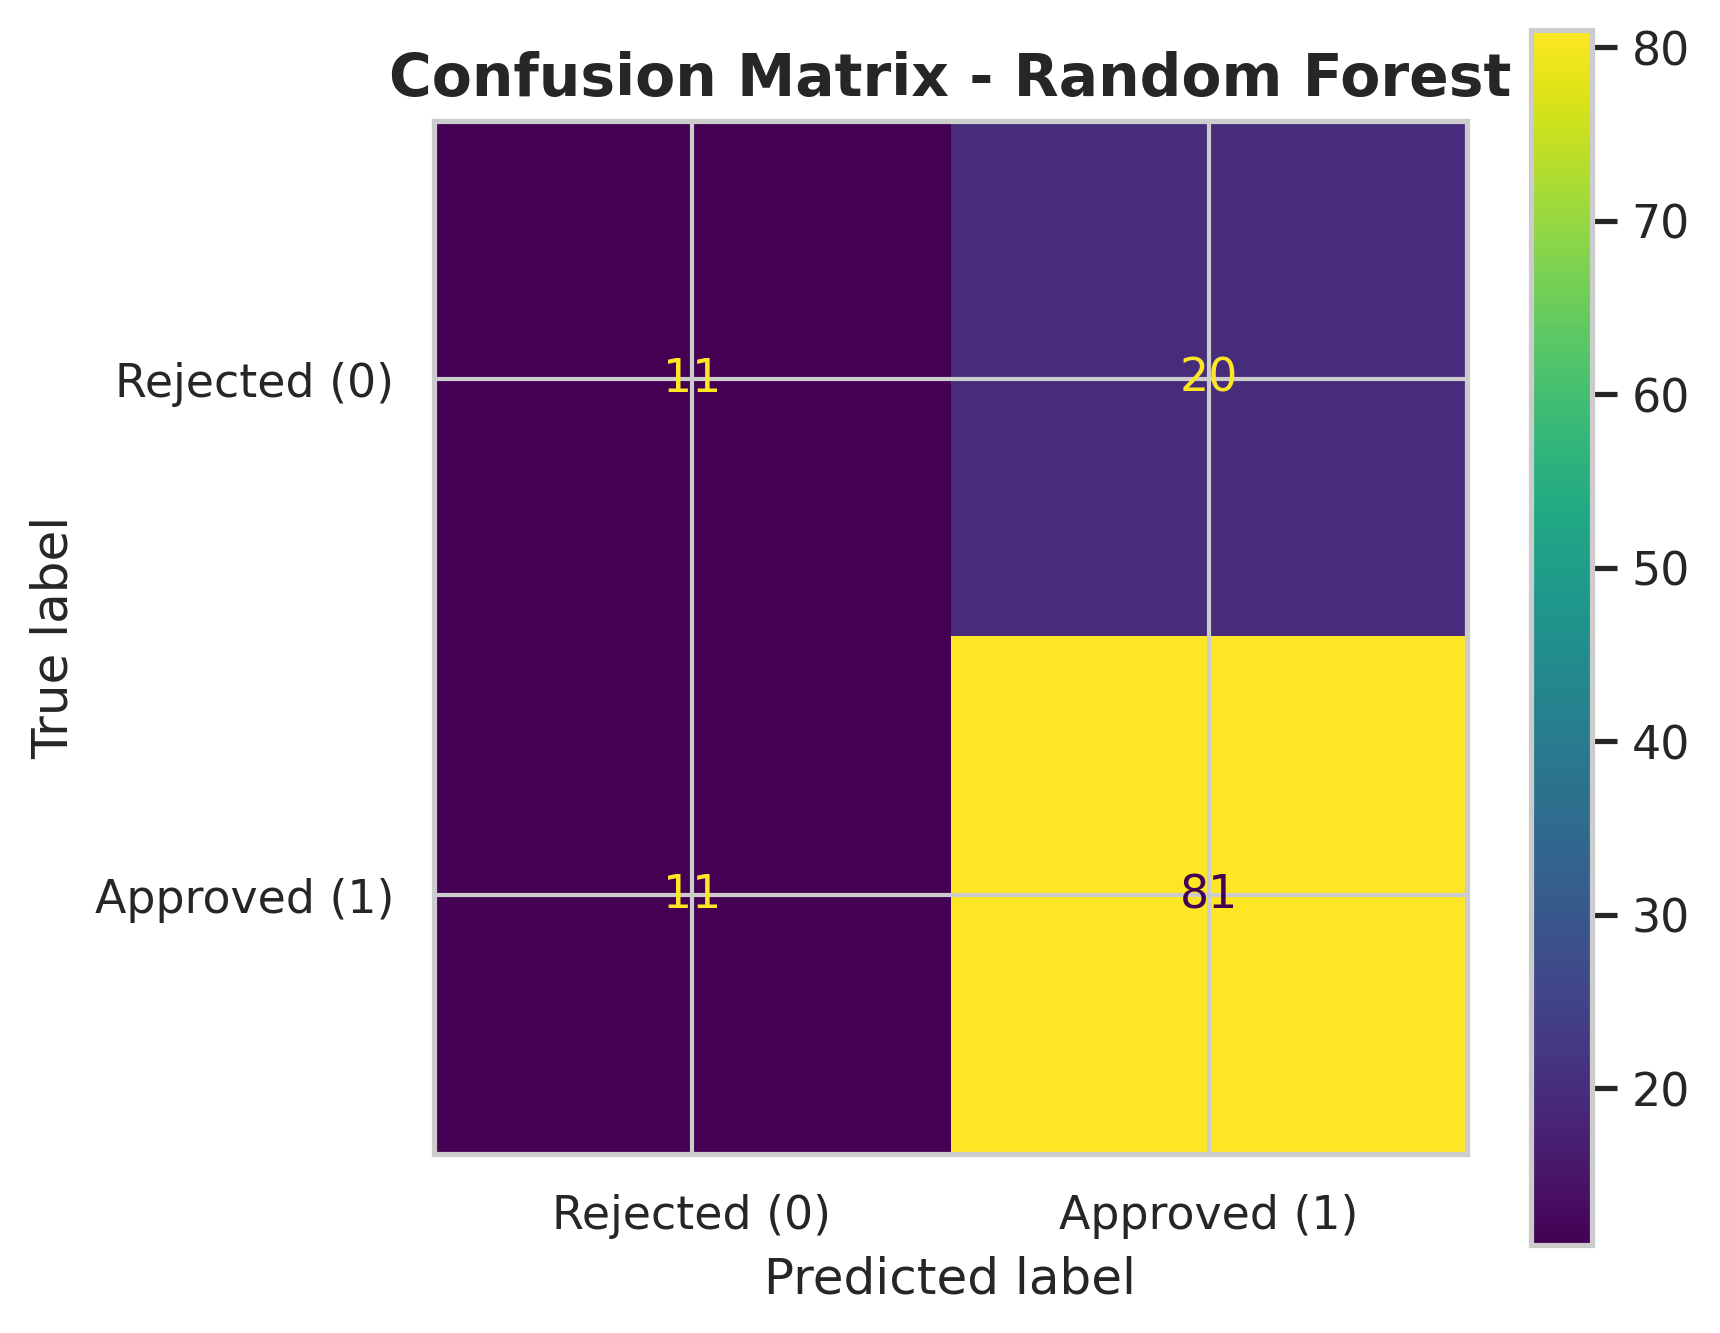

In [2]:
all_metrics = {}
probabilities = {}
filename_map = {
    'Logistic Regression': 'logistic_confusion_matrix.png',
    'Decision Tree': 'decision_tree_confusion_matrix.png',
    'Random Forest': 'random_forest_confusion_matrix.png',
}

for model_name, model in models.items():
    X_eval = X_test_scaled if model_name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    metrics = evaluate_model(model_name, y_test.values, y_pred, y_proba)
    all_metrics[model_name] = metrics
    probabilities[model_name] = y_proba
    plot_confusion_matrix(y_test.values, y_pred, model_name, config.IMAGES_DIR / filename_map[model_name])
    display(Image(filename=str(config.IMAGES_DIR / filename_map[model_name])))

## Combined ROC Curve

[2026-07-31 19:28:19] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/roc_curve.png


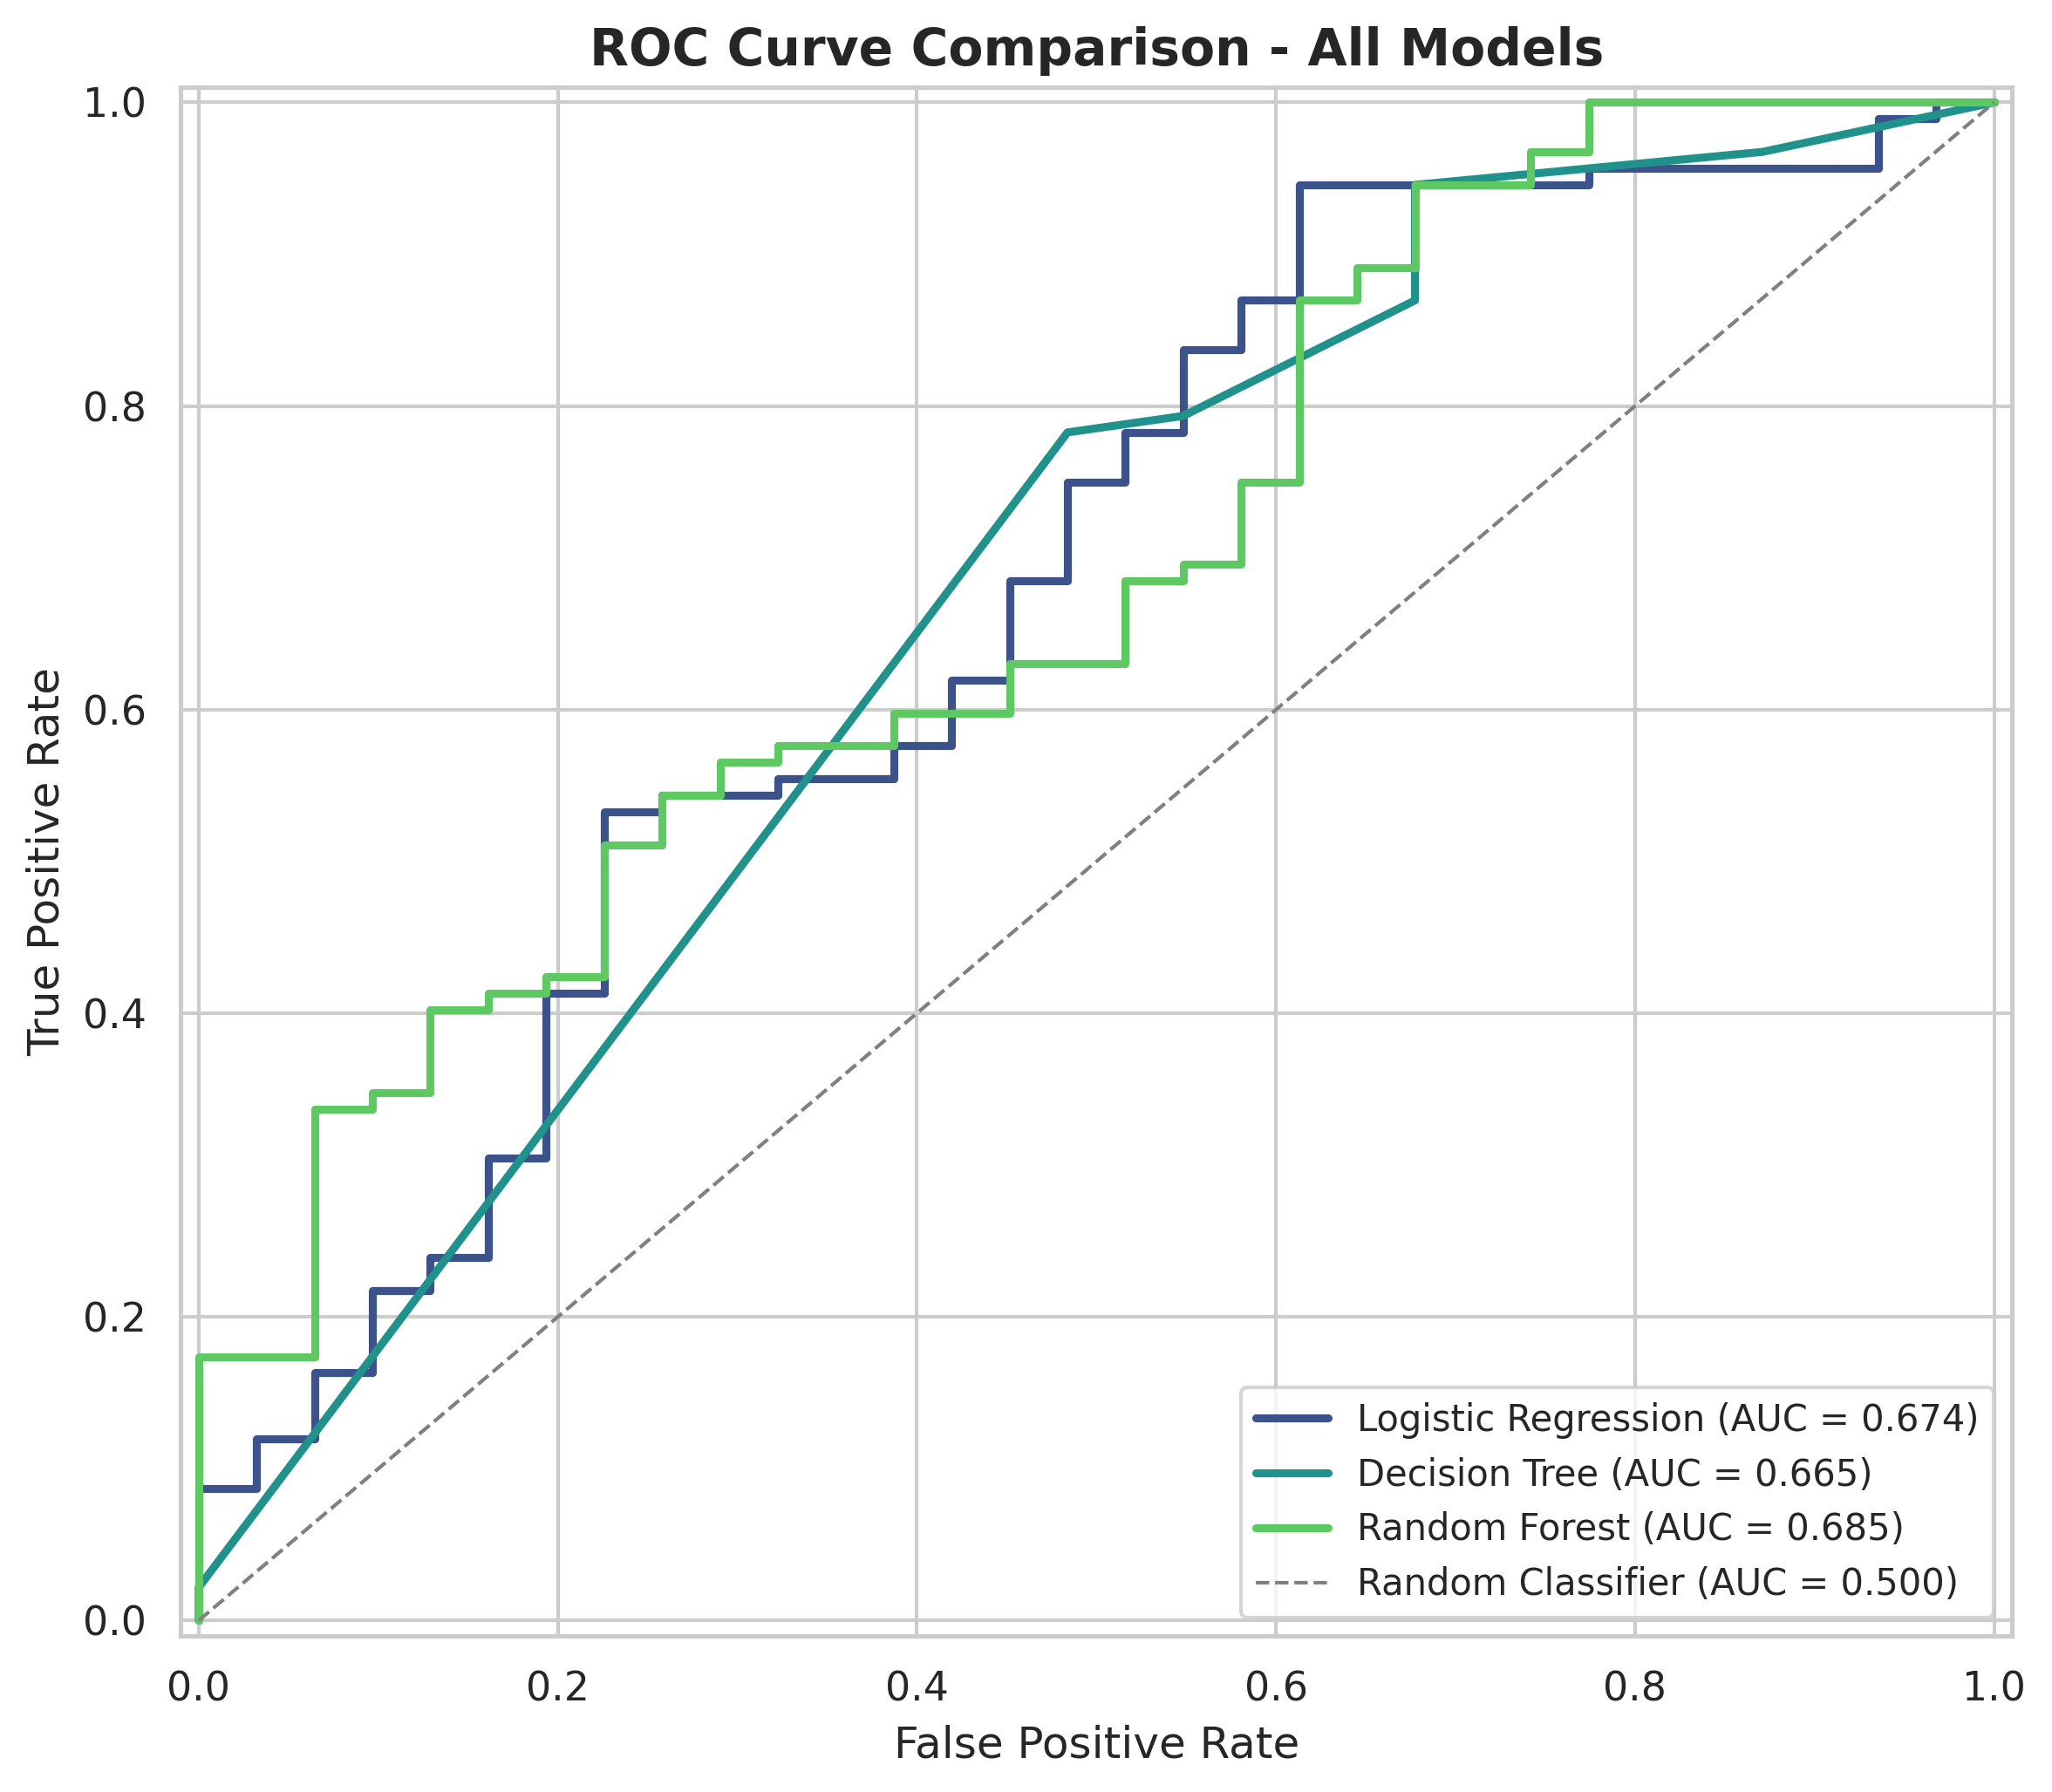

In [3]:
plot_combined_roc_curve(y_test.values, probabilities, config.IMAGES_DIR / 'roc_curve.png')
display(Image(filename=str(config.IMAGES_DIR / 'roc_curve.png')))

## Feature Importance (Random Forest)

[2026-07-31 19:28:20] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/feature_importance.png


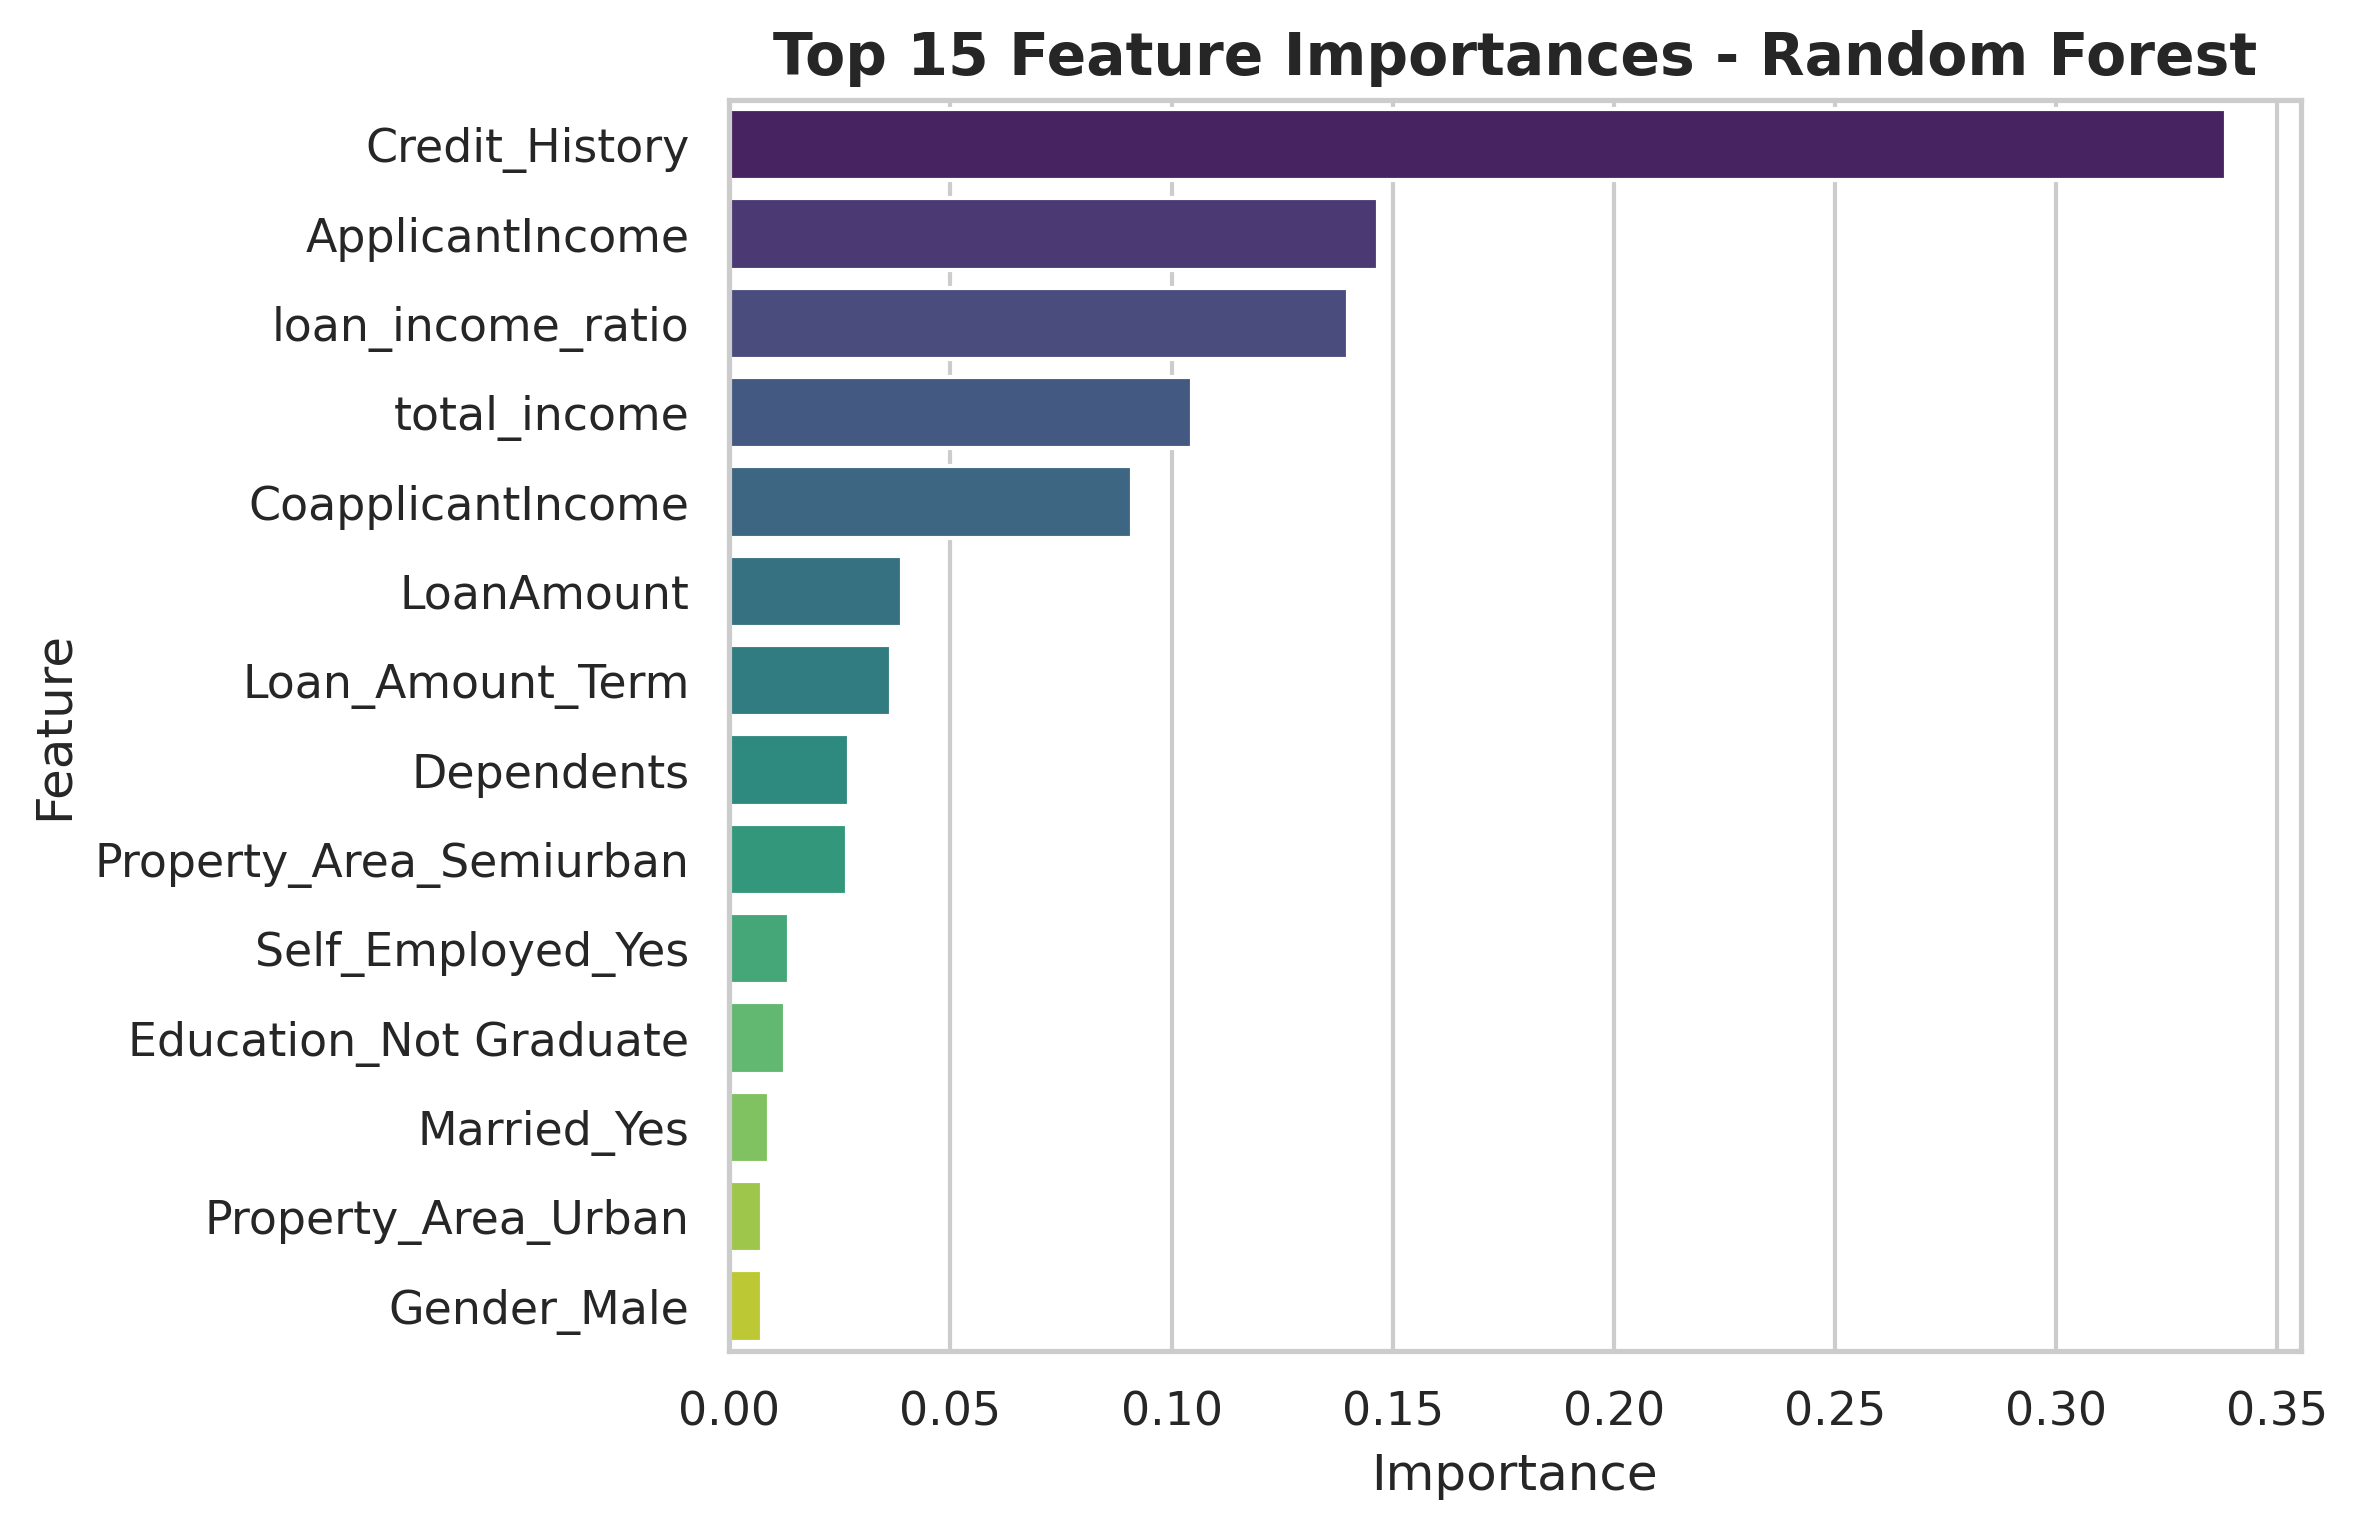

In [4]:
plot_feature_importance(
    list(X_test.columns), random_forest.feature_importances_,
    'Random Forest', config.IMAGES_DIR / 'feature_importance.png'
)
display(Image(filename=str(config.IMAGES_DIR / 'feature_importance.png')))

## Final Model Comparison Table

In [5]:
comparison_df = build_comparison_table(all_metrics)
comparison_df.to_csv(config.MODEL_COMPARISON_PATH, index=False)
comparison_df


MODEL COMPARISON TABLE
              Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
      Random Forest  0.747967   0.801980 0.880435  0.839378 0.685484
Logistic Regression  0.715447   0.813187 0.804348  0.808743 0.673913
      Decision Tree  0.707317   0.811111 0.793478  0.802198 0.664797


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.747967,0.801980,0.880435,0.839378,0.685484
1,Logistic Regression,0.715447,0.813187,0.804348,0.808743,0.673913
2,Decision Tree,0.707317,0.811111,0.793478,0.802198,0.664797


[2026-07-31 19:28:20] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/model_comparison.png


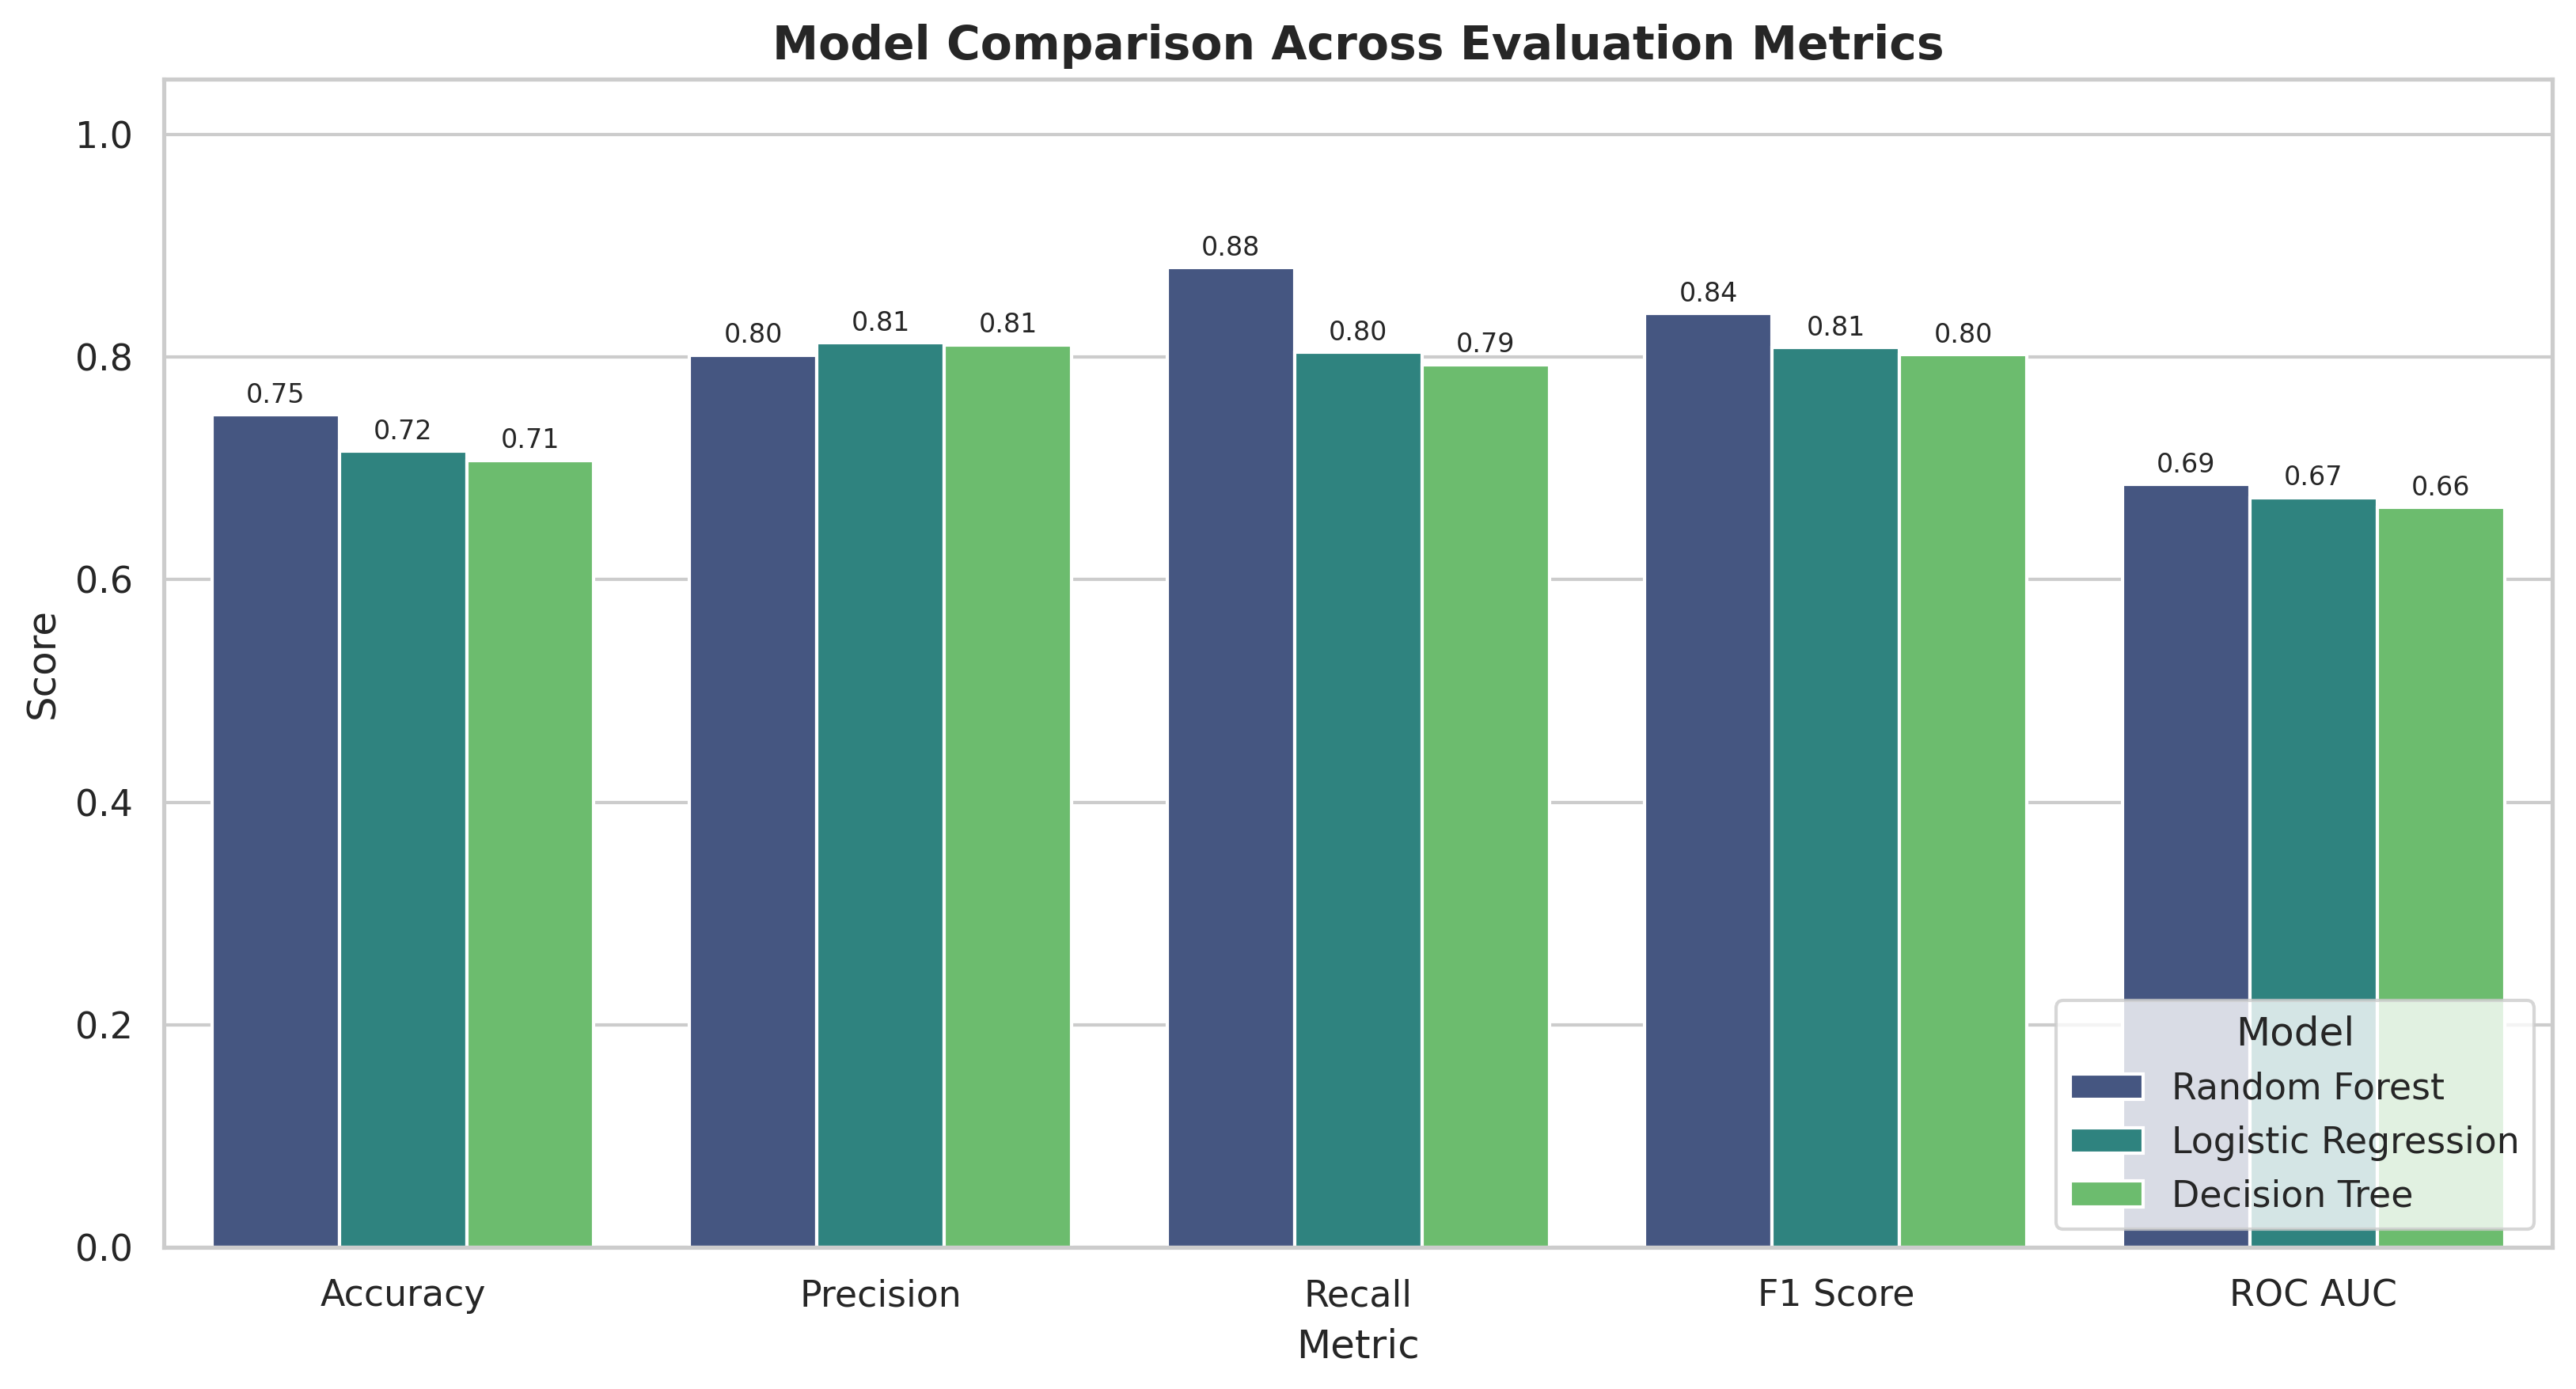

In [6]:
plot_model_comparison(comparison_df, config.IMAGES_DIR / 'model_comparison.png')
display(Image(filename=str(config.IMAGES_DIR / 'model_comparison.png')))

In [7]:
best_model = get_best_model_name(comparison_df, metric='ROC AUC')
print(f'Best performing model (by ROC AUC): {best_model}')

Best performing model (by ROC AUC): Random Forest


## Conclusion

All three models were evaluated on an identical, untouched 20% test split. The model comparison table and combined ROC curve above provide a direct, apples-to-apples comparison across Accuracy, Precision, Recall, F1 Score, and ROC-AUC. The model with the highest ROC-AUC is carried forward as the candidate for deployment, formalized in `reports/deployment_recommendation.md` and `05_Final_Report.ipynb`.